# Train Driver Behavior Model

Notebook nay doc du lieu feature da xu ly, train mot vai model co ban, danh gia va luu model tot nhat.

In [8]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import pandas as pd

try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
plt.style.use("ggplot")

## 1. Nap thu vien

Cell nay import cac thu vien can thiet cho viec doc du lieu, tien xu ly, train model, danh gia va luu model.

In [9]:
DATA_CANDIDATES = [
    Path("dataset_final_v2.csv"),
    Path("output/dataset_final_v2.csv"),
]

DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Khong tim thay dataset_final_v2.csv")

TARGET_COL = "label"
META_COLS = ["trip_id", "behavior", "label"]
FEATURE_COLS = ["speed_mean", "speed_std", "accel_long_std", "accel_lat_std", "distance_km"]

df = pd.read_csv(DATA_PATH)
df.head()

,trip_id,behavior,label,speed_mean,speed_std,accel_long_std,accel_lat_std,distance_km
0,20151110175712-16km-D1-NORMAL1-SECONDARY,NORMAL1,0,0.363782,0.631467,0.002490,0.003191,0.063056
1,20151110180824-16km-D1-NORMAL2-SECONDARY,NORMAL2,0,0.452951,0.677528,0.002400,0.003172,0.078889
2,20151111123124-25km-D1-NORMAL-MOTORWAY,NORMAL,0,0.165509,0.483005,0.002512,0.004966,0.039722
3,20151111125233-24km-D1-AGGRESSIVE-MOTORWAY,AGGRESSIVE,1,0.166893,0.489665,0.002761,0.003027,0.034167
4,20151111132348-25km-D1-DROWSY-MOTORWAY,DROWSY,2,0.581470,0.757702,0.002159,0.002761,0.151667


## 2. Doc du lieu

Notebook se uu tien doc file `dataset_final_v2.csv`. Neu file nam trong thu muc `output/` thi notebook cung tu tim thay.

Tap du lieu hien tai gom:
- 3 cot metadata: `trip_id`, `behavior`, `label`
- 5 cot feature so de train model

In [10]:
print(f"Data path: {DATA_PATH}")
print(f"Shape: {df.shape}")
print("Label distribution:")
print(df[TARGET_COL].value_counts().sort_index())
display(df[FEATURE_COLS].describe().T)

Data path: dataset_final_v2.csv
Shape: (40, 8)
Label distribution:
label
0    17
1    11
2    12
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
speed_mean,40.0,0.330282,0.238751,0.034395,0.137904,0.229526,0.531689,0.912356
speed_std,40.0,0.553934,0.181633,0.182357,0.403761,0.518706,0.733295,0.832592
accel_long_std,40.0,0.002606,0.000506,0.002033,0.002324,0.002486,0.002715,0.004877
accel_lat_std,40.0,0.003779,0.003628,0.001837,0.002446,0.002882,0.003472,0.021118
distance_km,40.0,0.070292,0.054158,0.007500,0.030903,0.045556,0.114444,0.200833


## 3. Kham pha du lieu nhanh

Cell duoi day in ra kich thuoc dataset, phan bo nhan va thong ke mo ta cua cac feature de minh kiem tra nhanh chat luong du lieu truoc khi train.

In [11]:
X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (30, 5)
Test shape: (10, 5)


## 4. Chia tap train va test

Du lieu duoc tach thanh 2 phan:
- `train` de hoc model
- `test` de danh gia khach quan sau cung

Tham so `stratify=y` giup giu ty le cac lop gan giong tap du lieu ban dau.

In [12]:
numeric_preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer([
    ("num", numeric_preprocess, FEATURE_COLS),
])

models = {
    "logistic_regression": LogisticRegression(max_iter=1000),
    "random_forest": RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced"),
    "svm_rbf": SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, class_weight="balanced"),
}

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
results = []
pipelines = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro")
    pipelines[name] = pipe
    results.append({
        "model": name,
        "cv_f1_macro_mean": scores.mean(),
        "cv_f1_macro_std": scores.std(),
    })

results_df = pd.DataFrame(results).sort_values("cv_f1_macro_mean", ascending=False)
results_df

,model,cv_f1_macro_mean,cv_f1_macro_std
1,random_forest,0.765278,0.195646
2,svm_rbf,0.727778,0.029918
0,logistic_regression,0.691667,0.197066


## 5. Train va so sanh model

Phan nay dung `Pipeline` de dong goi tien xu ly va model trong cung mot luong xu ly.

Cac model duoc thu nghiem:
- Logistic Regression
- Random Forest
- SVM kernel RBF

Moc so sanh chinh la `F1-macro`, phu hop hon accuracy khi so lop co the khong can bang.

In [13]:
best_model_name = results_df.iloc[0]["model"]
best_pipeline = pipelines[best_model_name]
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Best model: {best_model_name}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test F1-macro: {test_f1:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

Best model: random_forest
Test accuracy: 0.9000
Test F1-macro: 0.8963

Classification report:
              precision    recall  f1-score   support

           0     0.8000    1.0000    0.8889         4
           1     1.0000    0.6667    0.8000         3
           2     1.0000    1.0000    1.0000         3

    accuracy                         0.9000        10
   macro avg     0.9333    0.8889    0.8963        10
weighted avg     0.9200    0.9000    0.8956        10



## 6. Danh gia model tot nhat

Sau khi chon duoc model co diem cross-validation tot nhat, notebook se fit lai tren tap train va danh gia tren tap test bang:
- Accuracy
- F1-macro
- Classification report

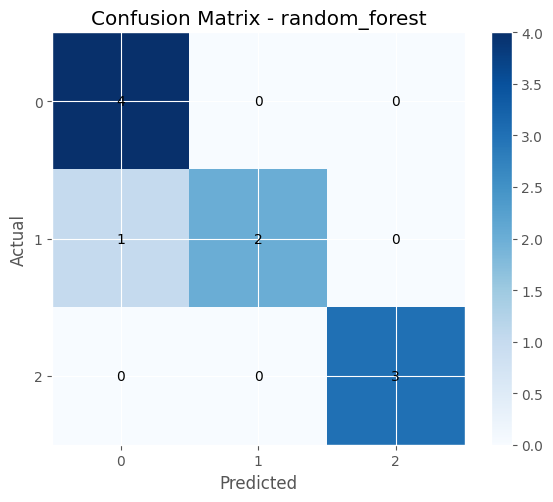

In [14]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.figure.colorbar(im, ax=ax)
ax.set_title(f"Confusion Matrix - {best_model_name}")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks(range(cm.shape[1]))
ax.set_yticks(range(cm.shape[0]))

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

## 7. Confusion matrix

Bieu do nay cho biet model dang du doan dung hay nham giua cac lop `NORMAL`, `AGGRESSIVE` va `DROWSY`.

In [15]:
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / "best_driver_behavior_model.joblib"

joblib.dump({
    "model_name": best_model_name,
    "feature_cols": FEATURE_COLS,
    "pipeline": best_pipeline,
}, MODEL_PATH)

print(f"Da luu model tai: {MODEL_PATH}")

Da luu model tai: models\best_driver_behavior_model.joblib


## 8. Luu model

Model tot nhat duoc luu duoi dang file `.joblib` de co the nap lai sau nay cho prediction hoac trien khai.